# Project 3 - AI Recommendation Logic


### Objective

Build a **Tech Stack Recommender** using Content-Based Filtering.  
Given a set of skills provided by the user, the system will recommend the most relevant job roles by measuring the mathematical similarity between the user profile vector and each job role vector in the dataset.

### Theoretical Foundation

The system is built on three core pillars:

1. **Vector Mapping** - Converting text tags (skills) into numerical arrays so machines can process them.
2. **TF-IDF Weighting** - Assigning higher importance to rare, specific skills and penalizing overly common ones.
3. **Cosine Similarity** - Measuring the angular alignment between the user profile vector and each job role vector, independent of vector magnitude.

### Pipeline Architecture

INPUT (User Skills)  -->  PROCESS (TF-IDF + Cosine Similarity)  -->  OUTPUT (Top-N Job Roles)

The 4-step ranking pipeline:
- Step 1: Ingestion - Capture user skill inputs
- Step 2: Scoring - Compute cosine similarity for every job role
- Step 3: Sorting - Rank results in descending order of score
- Step 4: Filtering - Return only the Top-N results

## Section 1 - Library Imports

No external dataset file is required: the job role dataset is defined directly in the notebook for portability.

In [24]:
# Standard library
import math

# Data manipulation
import pandas as pd
import numpy as np

# Scikit-learn: TF-IDF vectorizer and cosine similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Section 2 - Dataset Definition

### Interpretation

In a production environment this data would be loaded from a file such as `raw_skills.csv`.  
Here we define it inline as a Python dictionary.  
Each entry represents one **job role** (the "item" in our recommendation engine) and the list of skills associated with it.  
Skills are stored as a single space-separated string because that is the format the TF-IDF vectorizer expects.

This dataset covers 12 common tech roles spanning data, backend, frontend, cloud, security, and mobile tracks.

In [25]:
# Each job role is described by its associated skill tags.
# The skill string for each role acts as its "document" in the TF-IDF vocabulary space.

raw_data = [
    {"role": "Data Scientist",
     "skills": "python sql machine_learning data_analysis statistics pandas numpy scikit_learn tensorflow deep_learning"},

    {"role": "Data Engineer",
     "skills": "python sql spark hadoop kafka airflow etl data_pipelines cloud aws gcp"},

    {"role": "Machine Learning Engineer",
     "skills": "python tensorflow pytorch machine_learning deep_learning mlops docker kubernetes model_deployment"},

    {"role": "Backend Developer",
     "skills": "python java nodejs rest_api sql databases docker microservices git authentication"},

    {"role": "Frontend Developer",
     "skills": "javascript react html css typescript redux responsive_design git ui_ux rest_api"},

    {"role": "Full Stack Developer",
     "skills": "javascript python react nodejs rest_api sql databases docker git html css"},

    {"role": "DevOps Engineer",
     "skills": "docker kubernetes aws ci_cd linux bash terraform ansible git monitoring cloud"},

    {"role": "Cloud Architect",
     "skills": "aws gcp azure cloud networking terraform kubernetes infrastructure security devops cost_optimization"},

    {"role": "Cybersecurity Analyst",
     "skills": "networking security penetration_testing linux firewalls encryption vulnerability_assessment siem incident_response"},

    {"role": "Mobile Developer",
     "skills": "flutter dart kotlin swift android ios rest_api firebase ui_ux git"},

    {"role": "Business Intelligence Analyst",
     "skills": "sql power_bi tableau excel data_analysis statistics reporting dashboards python business_logic"},

    {"role": "Systems Administrator",
     "skills": "linux windows networking bash powershell servers virtualization active_directory security monitoring"}
]

df = pd.DataFrame(raw_data)
print(f"Dataset loaded: {len(df)} job roles defined.\n")
print(df[["role"]].to_string(index=True))

Dataset loaded: 12 job roles defined.

                             role
0                  Data Scientist
1                   Data Engineer
2       Machine Learning Engineer
3               Backend Developer
4              Frontend Developer
5            Full Stack Developer
6                 DevOps Engineer
7                 Cloud Architect
8           Cybersecurity Analyst
9                Mobile Developer
10  Business Intelligence Analyst
11          Systems Administrator


## Section 3 - TF-IDF Vectorization

**Why not plain binary overlap?**  
A simple approach would assign 1 if a skill is present and 0 if absent.  
The problem is that this treats a generic skill like `python` (which appears in almost every role) with the same weight as a highly specific skill like `penetration_testing` (which appears in very few roles).  
Generic skills would dominate the similarity score and produce misleading results.

**TF-IDF solves this:**

- **Term Frequency (TF)** = count of a term in one document / total terms in that document  
  Rewards skills that appear frequently within a specific role.

- **Inverse Document Frequency (IDF)** = log(total documents / documents containing the term)  
  Penalizes skills that appear across many roles (they carry less discriminative power).

- **TF-IDF weight = TF x IDF**  
  Unique, role-specific skills receive high weights. Common skills receive low weights.

The logarithm in the IDF formula creates a **dampening effect**: the penalty grows slowly as frequency increases, keeping all values in a comparable numerical range.

### Implementation Note

We fit the TF-IDF vectorizer on the job role corpus only.  
The vocabulary (the set of known skill tokens) is learned from this corpus.  
The user input will then be **transformed** using this same vocabulary - this is critical.  
Item features and user features must map to the exact same vocabulary space, otherwise the cosine similarity math will fail.

In [26]:
# Initialize the TF-IDF vectorizer.
# We set token_pattern to match alphanumeric tokens including underscores
# so that compound skills like 'machine_learning' are treated as single tokens.

vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b[\w]+\b")

# Fit and transform: the vectorizer learns the vocabulary from the job role corpus
# and immediately converts each role's skill string into a TF-IDF weighted vector.
job_matrix = vectorizer.fit_transform(df["skills"])

vocabulary = vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(vocabulary)} unique skill tokens\n")
print("Sample vocabulary tokens:")
print(list(vocabulary[:20]))

print(f"\nJob role matrix shape: {job_matrix.shape}")
print("  Rows = job roles, Columns = vocabulary dimensions (one per unique skill)")

Vocabulary size: 75 unique skill tokens

Sample vocabulary tokens:
['active_directory', 'airflow', 'android', 'ansible', 'authentication', 'aws', 'azure', 'bash', 'business_logic', 'ci_cd', 'cloud', 'cost_optimization', 'css', 'dart', 'dashboards', 'data_analysis', 'data_pipelines', 'databases', 'deep_learning', 'devops']

Job role matrix shape: (12, 75)
  Rows = job roles, Columns = vocabulary dimensions (one per unique skill)


## Section 4 - Cosine Similarity

### Why Not Euclidean Distance?

Euclidean distance measures the straight-line geometric gap between two points.  
It is highly sensitive to **vector magnitude**.  
A role with a very long skill description and a role with a short one may appear far apart even if their skill orientations are nearly identical.  
This produces unreliable results when comparing text documents of different lengths.

### Cosine Similarity

Cosine similarity measures the **angle** between two vectors, making it invariant to magnitude.  
Only the orientation (direction) of preferences matters, not the total number of skills listed.

Formule:

```
cos(theta) = (A . B) / (||A|| * ||B||)
```

Score interpretation:
- Score = 1.0 : perfect alignment (identical orientation)
- Score = 0.5 : moderate overlap
- Score = 0.0 : no shared characteristics (orthogonal vectors)

Because TF-IDF values are non-negative, cosine scores in this system will always fall between 0 and 1, creating an intuitive percentage-style match indicator.

## Section 5 - The Recommendation Function

The function implements 4 step:

1. **Ingestion** - Accept a list of skill strings from the user
2. **Scoring** - Transform the user profile using the fitted vectorizer and compute cosine similarity against every job role vector
3. **Sorting** - Rank all job roles by their similarity score in descending order
4. **Filtering** - Return only the Top-N results to prevent choice overload

=>If the user's input contains no recognized skills (all scores equal zero), the system returns a helpful message instead of a meaningless empty list.

In [27]:
def recommend_roles(user_skills: list, top_n: int = 3) -> pd.DataFrame:
    # Step 1: Ingestion
    # Join the user's skill into one list.
    user_profile_string = " ".join(user_skills).lower()

    # use .transform(), not .fit_transform().
    #This maps the user's skills into the same dimensional space as the job roles, making the dot product mathematically valid.
    #Any skill the user enters that does not exist in the vocabulary will be silently ignored - this is expected behavior.
    user_vector = vectorizer.transform([user_profile_string])

    # If the user vector is entirely zero similarity
    if user_vector.nnz == 0:
        print("None of the entered skills are in the known vocabulary.")
        print("Please enter skills from the following list:")
        print(list(vectorizer.get_feature_names_out()))
        return pd.DataFrame()

    # Scoring :
    # Compute cosine similarity between the user vector (1 row)
    # and every job role vector (12 rows). Result is a 1 x 12 array.
    scores = cosine_similarity(user_vector, job_matrix).flatten()

    # Attach scores to the dataframe for easy handling
    results = df.copy()
    results["similarity_score"] = scores

    # Step 3: Sorting in descending order.
    results = results.sort_values(by="similarity_score", ascending=False).reset_index(drop=True)

    # Step 4: Filtering (Top-N)
    top_results = results.head(top_n)[["role", "similarity_score"]].copy()
    top_results["rank"] = range(1, top_n + 1)
    top_results["match_percentage"] = (top_results["similarity_score"] * 100).round(2).astype(str) + "%"
    top_results = top_results[["rank", "role", "similarity_score", "match_percentage"]]

    return top_results


print("Recommendation function defined successfully.")

Recommendation function defined successfully.


## Section 6 - Test and Results Interpretation

- **rank**: position in the final Top-N list (1 = best match)
- **role**: the recommended job title
- **similarity_score**: raw cosine value between 0.0 and 1.0
- **match_percentage**: the same score expressed as a percentage for readability

A score of 0.85 means the user's skill vector points in nearly the same direction as that job role's feature vector.  
A score of 0.05 means almost no shared characteristic orientation.

In [28]:
# Test Case 1: Data Science Profile
# Expected behavior: Data Scientist and ML Engineer should rank at the top.

user_input_1 = ["python", "machine_learning", "tensorflow", "deep_learning", "statistics"]

print("USER PROFILE - Test 1")
print("Skills provided:", user_input_1)

result_1 = recommend_roles(user_input_1, top_n=3)
print(result_1.to_string(index=False))


USER PROFILE - Test 1
Skills provided: ['python', 'machine_learning', 'tensorflow', 'deep_learning', 'statistics']
 rank                          role  similarity_score match_percentage
    1                Data Scientist          0.665144           66.51%
    2     Machine Learning Engineer          0.546122           54.61%
    3 Business Intelligence Analyst          0.204196           20.42%


Interpretation:

The profile strongly matches Data Science and Machine Learning roles. Data Scientist is the best match (66.51%), followed by Machine Learning Engineer (54.61%), due to the presence of Python, TensorFlow, Deep Learning, and Machine Learning skills. Business Intelligence Analyst has a lower match (20.42%), indicating that the profile is more focused on AI and data-driven modeling than business analytics.

In [29]:
# Test Case 2: Frontend Development Profile

user_input_2 = ["javascript", "react", "css", "html", "typescript", "ui_ux"]

print("USER PROFILE - Test 3")
print("Skills provided:", user_input_2)

result_2 = recommend_roles(user_input_2, top_n=3)
print(result_2.to_string(index=False))

USER PROFILE - Test 3
Skills provided: ['javascript', 'react', 'css', 'html', 'typescript', 'ui_ux']
 rank                 role  similarity_score match_percentage
    1   Frontend Developer          0.788876           78.89%
    2 Full Stack Developer          0.537235           53.72%
    3     Mobile Developer          0.116280           11.63%


Interpretation:
  Skills like react, typescript, css, and html are exclusive to the Frontend
  Developer and Full Stack Developer role descriptions. The IDF weight of
  'typescript' and 'responsive_design' is particularly high because they appear
  only in the Frontend role, creating strong directional alignment.



## Section 7 - Interactive User Interface


In [30]:
# Iteractive Recommendation Cell

my_skills = [
    "python",
    "sql",
    "data_analysis",
    "power_bi",
    "statistics"
]

# Minimum input validation
if len(my_skills) < 3:
    print("Error: Please provide at least 3 skills for accurate matching.")
else:
    print("Running recommendation engine...")
    print(f"Input skills: {my_skills}")
    print("=" * 60)
    my_results = recommend_roles(my_skills, top_n=3)
    if not my_results.empty:
        print("Top 3 Recommended Job Roles:")
        print(my_results.to_string(index=False))

Running recommendation engine...
Input skills: ['python', 'sql', 'data_analysis', 'power_bi', 'statistics']
Top 3 Recommended Job Roles:
 rank                          role  similarity_score match_percentage
    1 Business Intelligence Analyst          0.623152           62.32%
    2                Data Scientist          0.449005            44.9%
    3          Full Stack Developer          0.154705           15.47%


## Section 8 - Visualizing the Score Distribution

Visualizing all similarity scores (not just the Top-3) allows us to understand the full distribution of the recommendation output.  


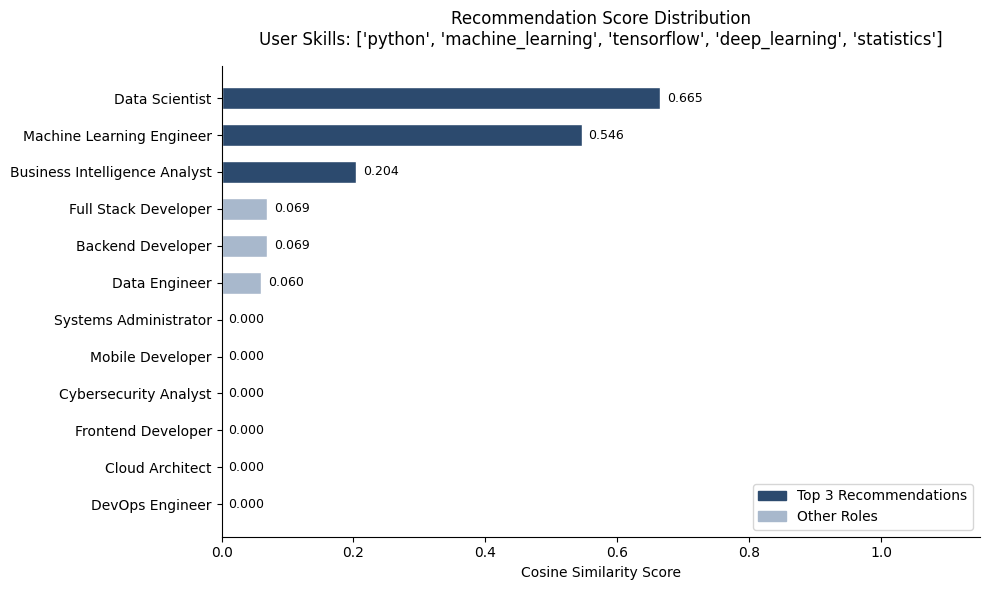

Chart saved to: outputs/recommendation_scores.png


In [31]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import cosine_similarity

def visualize_scores(user_skills: list, top_n: int = 3):
    """
    Computes similarity scores for all roles and plots a horizontal bar chart
    showing the full score distribution. Top-N bars are highlighted.
    """
    user_profile_string = " ".join(user_skills).lower()
    user_vector = vectorizer.transform([user_profile_string])

    if user_vector.nnz == 0:
        print("Cold Start: cannot visualize. No recognized skills found.")
        return

    scores = cosine_similarity(user_vector, job_matrix).flatten()
    results = df.copy()
    results["score"] = scores
    results = results.sort_values(by="score", ascending=True)

    # Color: dark for top-N, light for the rest
    top_roles = set(results.tail(top_n)["role"].values)
    colors = ["#2c4a6e" if role in top_roles else "#a8b8cc"
              for role in results["role"]]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(
        results["role"],
        results["score"],
        color=colors,
        edgecolor="white",
        height=0.6
    )

    # Score labels on bars
    for bar, score in zip(bars, results["score"]):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.3f}",
            va="center",
            ha="left",
            fontsize=9
        )

    ax.set_xlim(0, 1.15)
    ax.set_xlabel("Cosine Similarity Score")
    ax.set_title(
        f"Recommendation Score Distribution\nUser Skills: {user_skills}",
        pad=15
    )

    top_patch = mpatches.Patch(
        color="#2c4a6e",
        label=f"Top {top_n} Recommendations"
    )
    other_patch = mpatches.Patch(
        color="#a8b8cc",
        label="Other Roles"
    )
    ax.legend(handles=[top_patch, other_patch], loc="lower right")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    # Save image
    output_dir = "outputs"
    os.makedirs(output_dir, exist_ok=True)

    file_path = os.path.join(output_dir, "recommendation_scores.png")
    plt.savefig(file_path, dpi=150, bbox_inches="tight")

    plt.show()
    print(f"Chart saved to: {file_path}")

# Visualize for Test Case 1
visualize_scores([
    "python",
    "machine_learning",
    "tensorflow",
    "deep_learning",
    "statistics"
])

## Section 9 - Examining the TF-IDF Weights

This diagnostic cell allows us to inspect the actual TF-IDF weight assigned to each skill in the vocabulary.

In [32]:
idf_values = vectorizer.idf_
vocab = vectorizer.get_feature_names_out()

idf_df = pd.DataFrame({"skill": vocab, "idf_weight": idf_values})
idf_df = idf_df.sort_values(by="idf_weight", ascending=False).reset_index(drop=True)

print("Top 15 skills with highest IDF weight (most discriminative - rare, specific):")
print(idf_df.head(15).to_string(index=False))
print()
print("Bottom 10 skills with lowest IDF weight (most generic - appear across many roles):")
print(idf_df.tail(10).to_string(index=False))

Top 15 skills with highest IDF weight (most discriminative - rare, specific):
            skill  idf_weight
 active_directory    2.871802
          airflow    2.871802
          android    2.871802
          ansible    2.871802
   authentication    2.871802
            azure    2.871802
   business_logic    2.871802
            ci_cd    2.871802
       dashboards    2.871802
             dart    2.871802
cost_optimization    2.871802
          windows    2.871802
   virtualization    2.871802
       typescript    2.871802
   data_pipelines    2.871802

Bottom 10 skills with lowest IDF weight (most generic - appear across many roles):
     skill  idf_weight
     cloud    2.178655
     linux    2.178655
  security    2.178655
networking    2.178655
kubernetes    2.178655
    docker    1.955511
  rest_api    1.955511
       git    1.773190
       sql    1.773190
    python    1.619039


## Section 10 - Conclusion

**Content-Based over Collaborative Filtering**  
Collaborative filtering requires large historical interaction datasets ("users who viewed this also viewed...").  
Content-based filtering works from item attributes (skill tags) alone, making it deployable immediately without any prior user interaction data.  
This also makes it naturally robust to the Item Cold Start problem: new job roles can be added and recommended as soon as their skill tags are defined.

**TF-IDF over Binary Vectors**  
Binary vectors treat all skills with equal importance.  
TF-IDF intelligently downweights generic skills (python, sql) that appear across many roles and upweights rare, specific skills (penetration_testing, mlops) that strongly identify a particular role.  
This produces more accurate, discriminative recommendations.

**Cosine Similarity over Euclidean Distance**  
Euclidean distance is sensitive to vector magnitude, which varies based on how many skills a role description contains.  
Cosine similarity is magnitude-invariant: it measures only the angular alignment of preference directions.  
This ensures that a role with a short skill list is not unfairly penalized against a role with an extensive one.

### Limitations and next steps

- The current vocabulary is static. A production system would rebuild the TF-IDF model periodically as new roles and skills are added.
- The system has no mechanism to learn from user feedback. Integrating implicit signals (clicks, time spent) would allow transition toward hybrid filtering.
- Skill synonyms are not handled ("ML" and "machine_learning" are treated as separate tokens). A normalization or embedding layer would address this.
- The dataset is small (12 roles). Scaling to hundreds of roles would increase vocabulary richness and recommendation accuracy.
